# SHAP: what drives the estimate, stage by stage

Three models, each adding features on top of the previous one:

1. **House only**: the house itself (size, rooms, age, lot, type).
   - **1b. House + accessibility** (side scenario): the house plus only its accessibility score, with no location
     or neighborhood price. Shows what accessibility is worth when nothing else about the location is known.
   - **1c. House + flood zone** (side scenario): the house plus only whether it is in a floodplain.
2. **+ Neighborhood**: where it is (`location`: area, coordinates, the neighborhood's sale count and price momentum)
   and the neighborhood's price level (`neighborhood_price`: median price per sq ft).
3. **+ Everything else**: accessibility, assigned-school scores, crime, floodplain and light rail.
   - **3b. Everything except the neighborhood price** (side scenario): the production `without_neighborhood_price`
     feature set. Shows where the neighborhood price's credit goes when the model doesn't have it.

All six use the same train/test split as `training.py`, so their errors can be compared directly.

**Reading SHAP values.** The models predict `log(1 + total_value)`, so a SHAP value is a change in log value.
For small values it is roughly a percent change: +0.10 means the feature raises the estimate by about 10.5%
for that house compared with the average house.

**Model.** Each stage is a histogram gradient boosting model, the production model type, with the production
settings from `reports/best_hyperparameters.json` and the same early stopping as `training.py` (up to 3,000 trees,
stopping after 50 rounds without improvement on an internal 10% split). Only the features differ between stages.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import json

from sklearn.ensemble import HistGradientBoostingRegressor

from src.components.evaluating import FEATURE_GROUPS
from src.components.training import (
    CATEGORICAL_FEATURES, FEATURE_COLUMNS, TARGET,
    build_preprocessor, eval_metrics, load_training_data, split_with_aggregates,
)
from src.utils.common import resolve_path
from src.utils.load_config import load_config

cfg = load_config()

/Users/a70411/Let-me-have-a-house/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature groups and stages

In [2]:
# FEATURE_GROUPS (from evaluating.py, shared with the drop-column test): house, location, neighborhood_price,
# accessibility, school, crime, flood, light_rail
print({group: len(features) for group, features in FEATURE_GROUPS.items()})

STAGES = {
    "1. house": ["house"],
    "1b. house + accessibility": ["house", "accessibility"],
    "1c. house + flood zone": ["house", "flood"],
    "2. + neighborhood": ["house", "location", "neighborhood_price"],
    "3. + everything": list(FEATURE_GROUPS),
    "3b. everything except neighborhood price": [g for g in FEATURE_GROUPS if g != "neighborhood_price"],
}

# production settings for the default feature set; early stopping as in training.build_search_estimators
best = json.loads((ROOT / "reports" / "best_hyperparameters.json").read_text())
MODEL_PARAMS = dict(**best["with_neighborhood_price__hist_gradient_boosting"],
                    max_iter=3000, early_stopping=True, validation_fraction=0.1, n_iter_no_change=50,
                    random_state=cfg["training"]["random_state"])
SHAP_SAMPLE = 500  # test houses explained per stage

{'house': 7, 'location': 5, 'neighborhood_price': 1, 'accessibility': 7, 'school': 3, 'crime': 2, 'flood': 1, 'light_rail': 1}


## Data

Same rows and split as `training.py`; neighborhood price features are computed from training rows only.

In [3]:
df = load_training_data(resolve_path(cfg, "features_data"))
train, test = split_with_aggregates(df, cfg["training"])
y_train = np.log1p(train[TARGET])
sample = test.sample(SHAP_SAMPLE, random_state=0)
print(f"{len(train):,} training houses, {len(test):,} test houses, {len(sample)} explained")

243,340 training houses, 60,839 test houses, 500 explained


In [4]:
def stage_features(stage):
    return [f for group in STAGES[stage] for f in FEATURE_GROUPS[group]]


def fit_stage(features):
    """Fit one model on `features`; return (preprocessor, model, test metrics in dollars)."""
    pre = build_preprocessor(features)
    model = HistGradientBoostingRegressor(**MODEL_PARAMS).fit(pre.fit_transform(train[features]), y_train)
    metrics = eval_metrics(test[TARGET], np.expm1(model.predict(pre.transform(test[features]))))
    return pre, model, metrics


def explain(pre, model, features, rows):
    """SHAP values per original feature: the one-hot columns of `area` and `land_use_class`
    are summed back into one value each."""
    explainer = shap.TreeExplainer(model)
    values = explainer.shap_values(pre.transform(rows[features]))
    names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
    owner = [next(f for f in features if n == f or (f in CATEGORICAL_FEATURES and n.startswith(f + "_")))
             for n in names]
    grouped = pd.DataFrame(values, columns=owner).T.groupby(level=0).sum().T[features]
    # categorical values are shown as codes, only for the beeswarm's colors
    data = rows[features].apply(lambda c: pd.factorize(c)[0] if c.name in CATEGORICAL_FEATURES else c)
    return shap.Explanation(grouped.to_numpy(), base_values=np.full(len(rows), np.ravel(explainer.expected_value)[0]),
                            data=data.to_numpy(dtype=float), feature_names=features)


def show(expl, title):
    shap.plots.bar(expl, max_display=15, show=False)
    plt.title(f"{title}: mean |SHAP|")
    plt.show()
    shap.plots.beeswarm(expl, max_display=15, show=False)
    plt.title(f"{title}: SHAP per house")
    plt.show()


def print_metrics(m):
    print(f"MAE ${m['mae']:,.0f}   RMSE ${m['rmse']:,.0f}   R squared {m['r2']:.3f}   average error {m['mape']:.2%}")


results, explanations, models = {}, {}, {}

## Stage 1: house only

MAE $87,566   RMSE $187,565   R squared 0.764   average error 15.19%


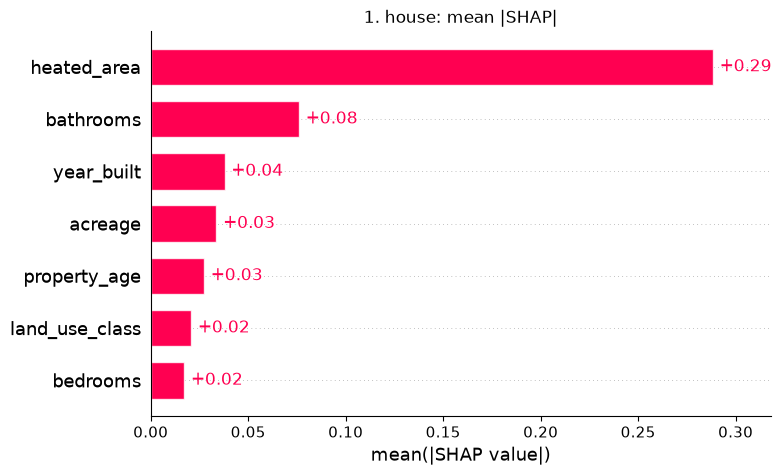

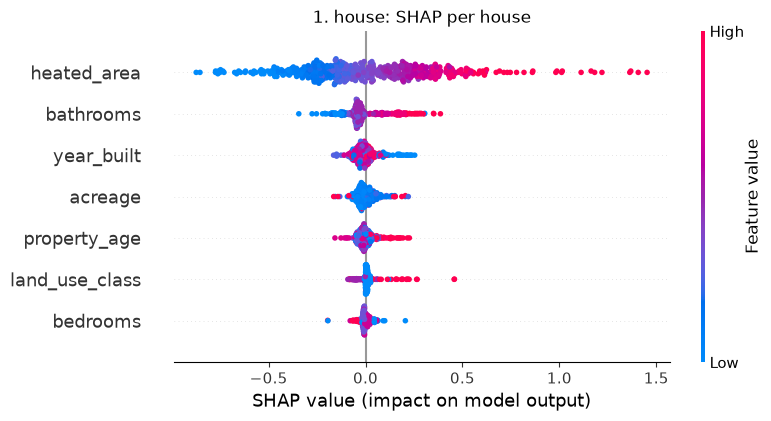

In [5]:
stage = "1. house"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 1b: house + accessibility

Only the house and its accessibility score: no area, coordinates or neighborhood price.

MAE $33,067   RMSE $83,518   R squared 0.953   average error 5.62%


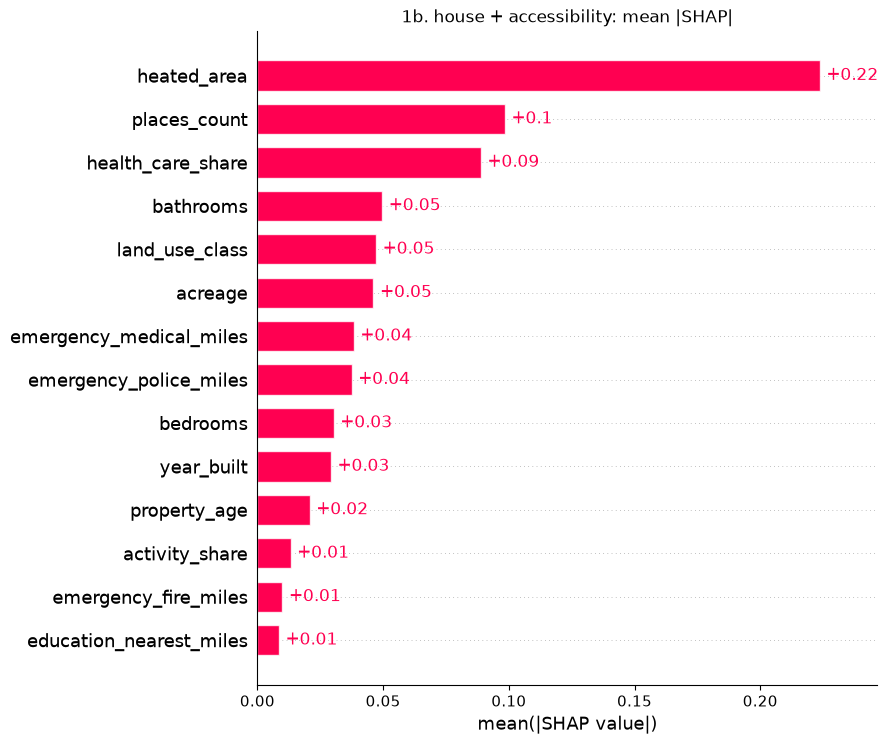

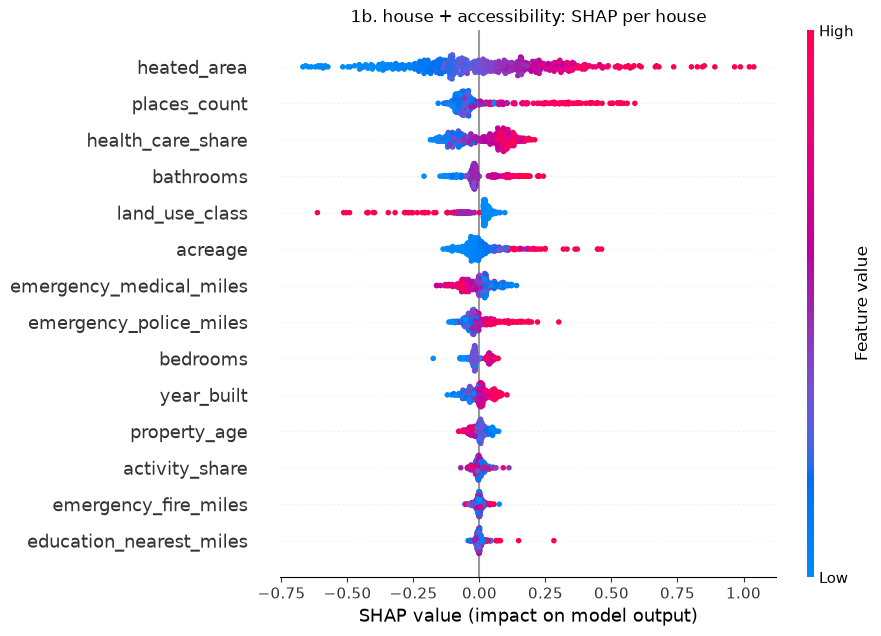

In [6]:
stage = "1b. house + accessibility"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 1c: house + flood zone

Only the house and whether it is in a floodplain.

MAE $87,337   RMSE $187,726   R squared 0.764   average error 15.15%


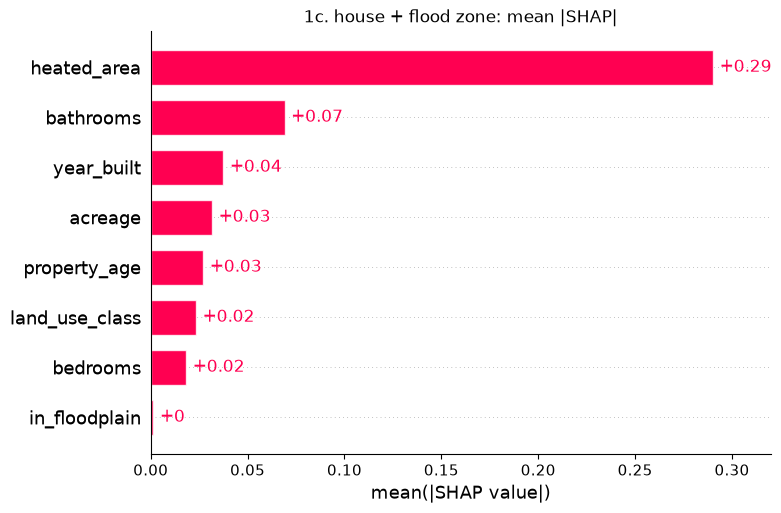

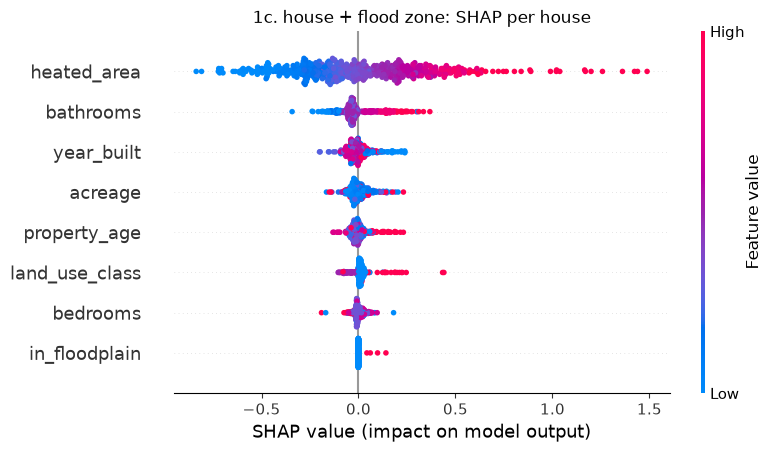

In [7]:
stage = "1c. house + flood zone"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 2: + neighborhood

MAE $30,682   RMSE $80,398   R squared 0.957   average error 5.25%


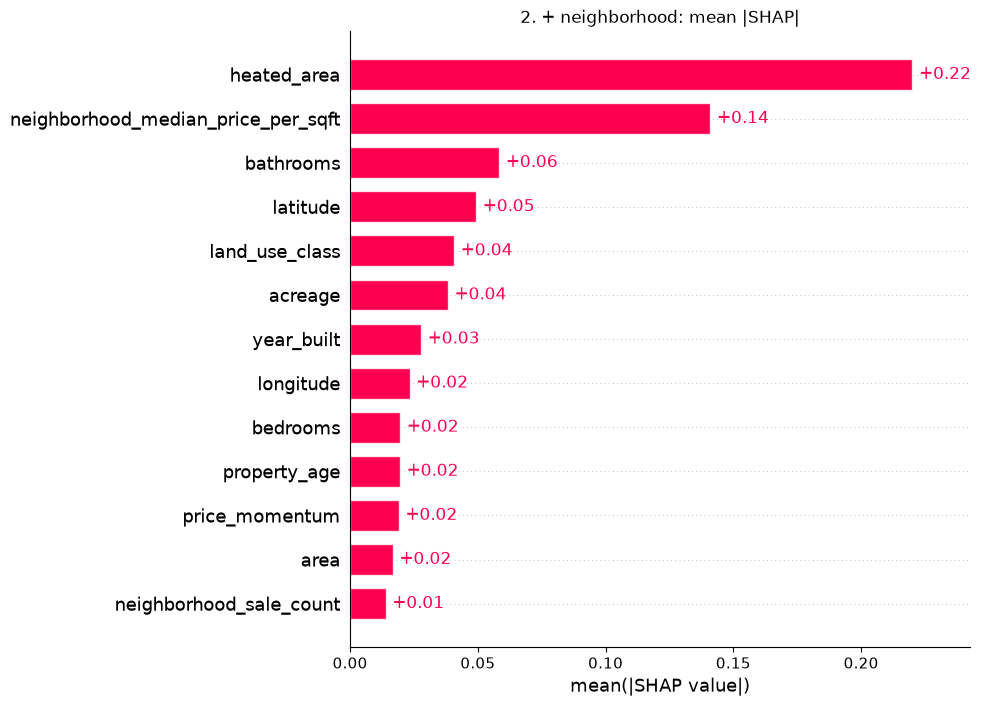

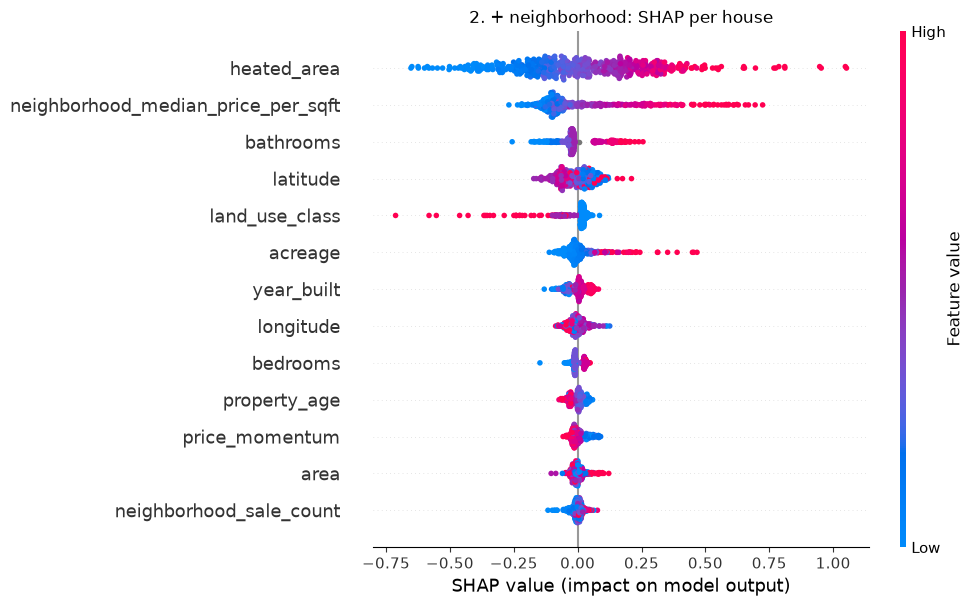

In [8]:
stage = "2. + neighborhood"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 3: + accessibility, school, crime, flood and rail

MAE $29,413   RMSE $74,386   R squared 0.963   average error 5.08%


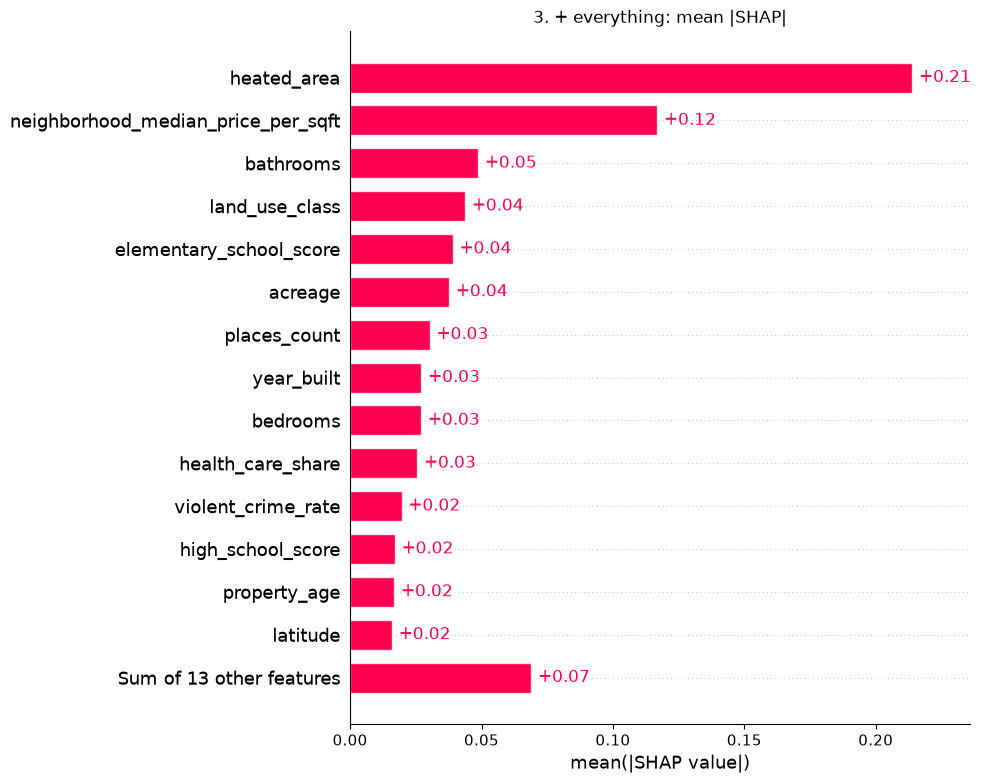

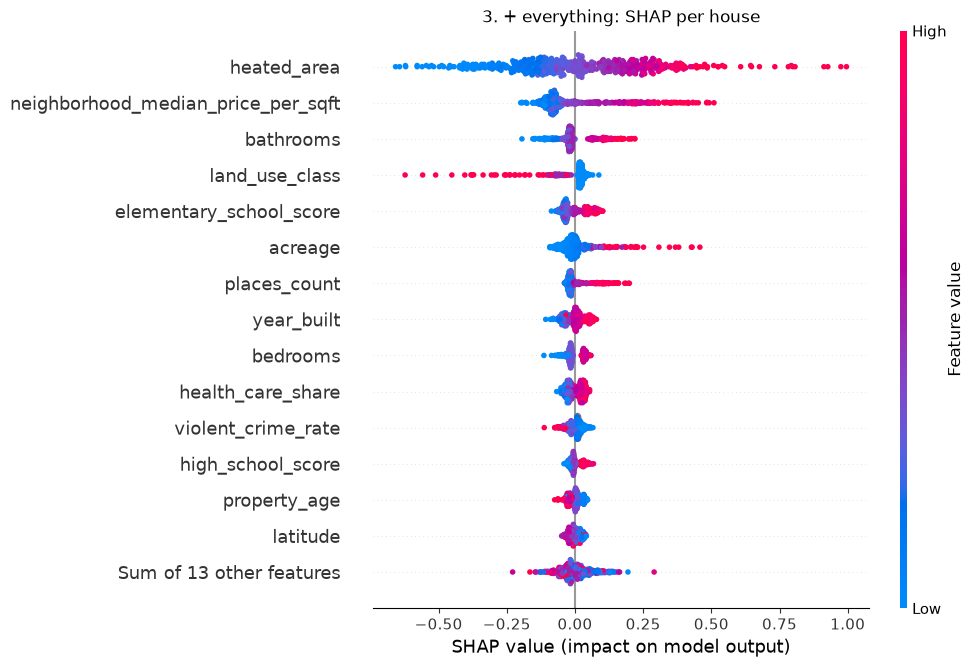

In [9]:
stage = "3. + everything"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Stage 3b: everything except the neighborhood price

The production `without_neighborhood_price` feature set: every feature but `neighborhood_median_price_per_sqft`.

MAE $29,862   RMSE $74,382   R squared 0.963   average error 5.18%


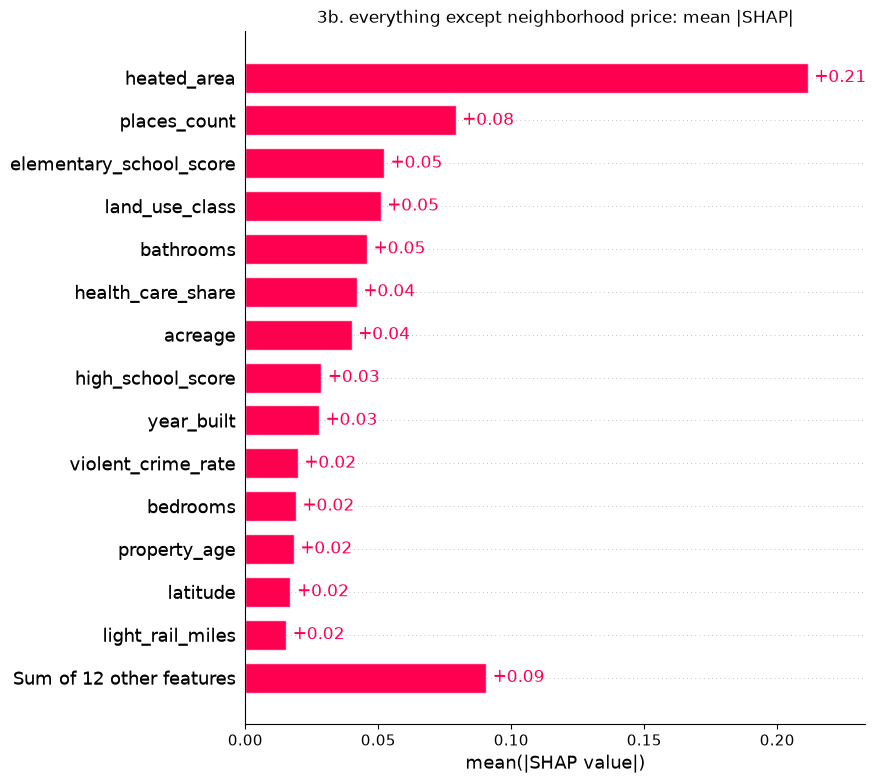

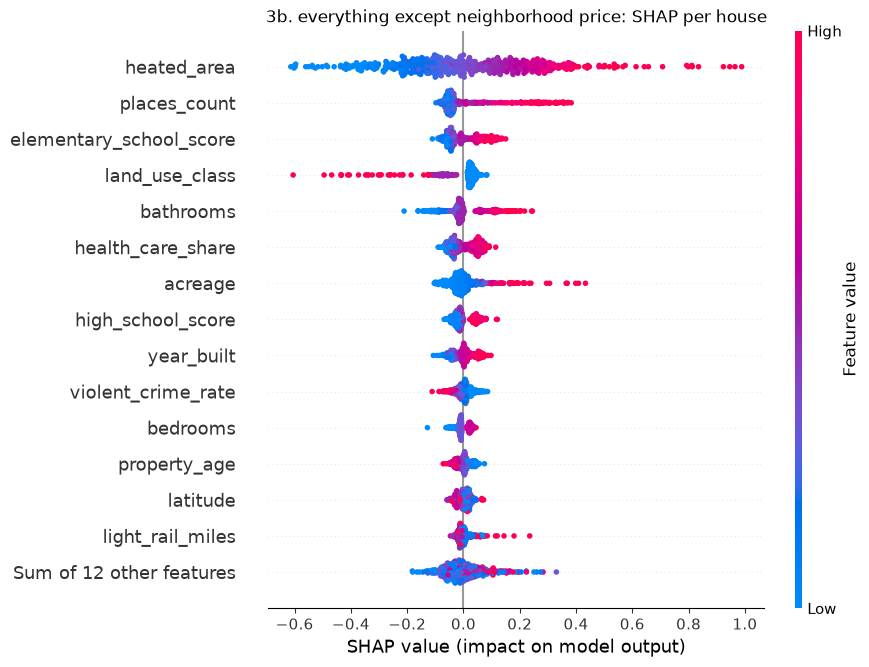

In [10]:
stage = "3b. everything except neighborhood price"
features = stage_features(stage)
pre, model, results[stage] = fit_stage(features)
models[stage] = pre, model, features
print_metrics(results[stage])
explanations[stage] = explain(pre, model, features, sample)
show(explanations[stage], stage)

## Comparison

Test error after each stage, and how much of the stage 3 and 3b predictions each feature group carries.

In [11]:
comparison = pd.DataFrame(results).T
comparison["mae"] = comparison["mae"].map("${:,.0f}".format)
comparison["rmse"] = comparison["rmse"].map("${:,.0f}".format)
comparison["mape"] = comparison["mape"].map("{:.2%}".format)
comparison["r2"] = comparison["r2"].round(3)
comparison

,rmse,mae,r2,mape
1. house,"$187,565","$87,566",0.764,15.19%
1b. house + accessibility,"$83,518","$33,067",0.953,5.62%
1c. house + flood zone,"$187,726","$87,337",0.764,15.15%
2. + neighborhood,"$80,398","$30,682",0.957,5.25%
3. + everything,"$74,386","$29,413",0.963,5.08%
3b. everything except neighborhood price,"$74,382","$29,862",0.963,5.18%


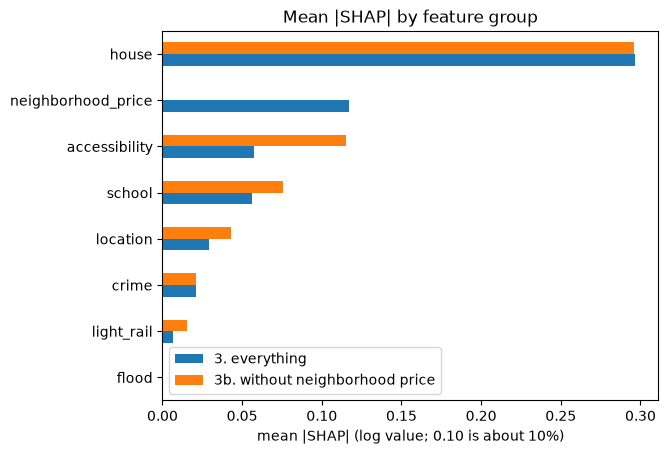

,3. everything,3b. without neighborhood price,change
house,0.2965,0.2962,-0.0002
neighborhood_price,0.1169,NaN,NaN
accessibility,0.0574,0.1150,0.0576
school,0.0562,0.0758,0.0196
location,0.0289,0.0431,0.0142
crime,0.0213,0.0212,-0.0002
light_rail,0.0065,0.0153,0.0089
flood,0.0004,0.0004,0.0000


In [12]:
# mean |SHAP| of each group's summed SHAP values, per house, with and without the neighborhood price
def group_importance(stage):
    expl = explanations[stage]
    by_feature = pd.DataFrame(expl.values, columns=expl.feature_names)
    return pd.Series({group: by_feature[[f for f in cols if f in by_feature]].sum(axis=1).abs().mean()
                      for group, cols in FEATURE_GROUPS.items() if any(f in by_feature for f in cols)})


groups = pd.DataFrame({"3. everything": group_importance("3. + everything"),
                       "3b. without neighborhood price": group_importance("3b. everything except neighborhood price")})
groups = groups.sort_values("3. everything")
groups.plot.barh(title="Mean |SHAP| by feature group")
plt.xlabel("mean |SHAP| (log value; 0.10 is about 10%)")
plt.show()
groups["change"] = groups["3b. without neighborhood price"] - groups["3. everything"]
groups.sort_values("3. everything", ascending=False).round(4)

## The test houses

Why the stage 3 model values each test house (`test_addresses` in `config/config.yaml`) the way it does, starting from the average house.

4817 Kelly Woods Ln, Charlotte NC 28277 - in test set; assessed $1,191,900, stage 3 estimate $1,283,815


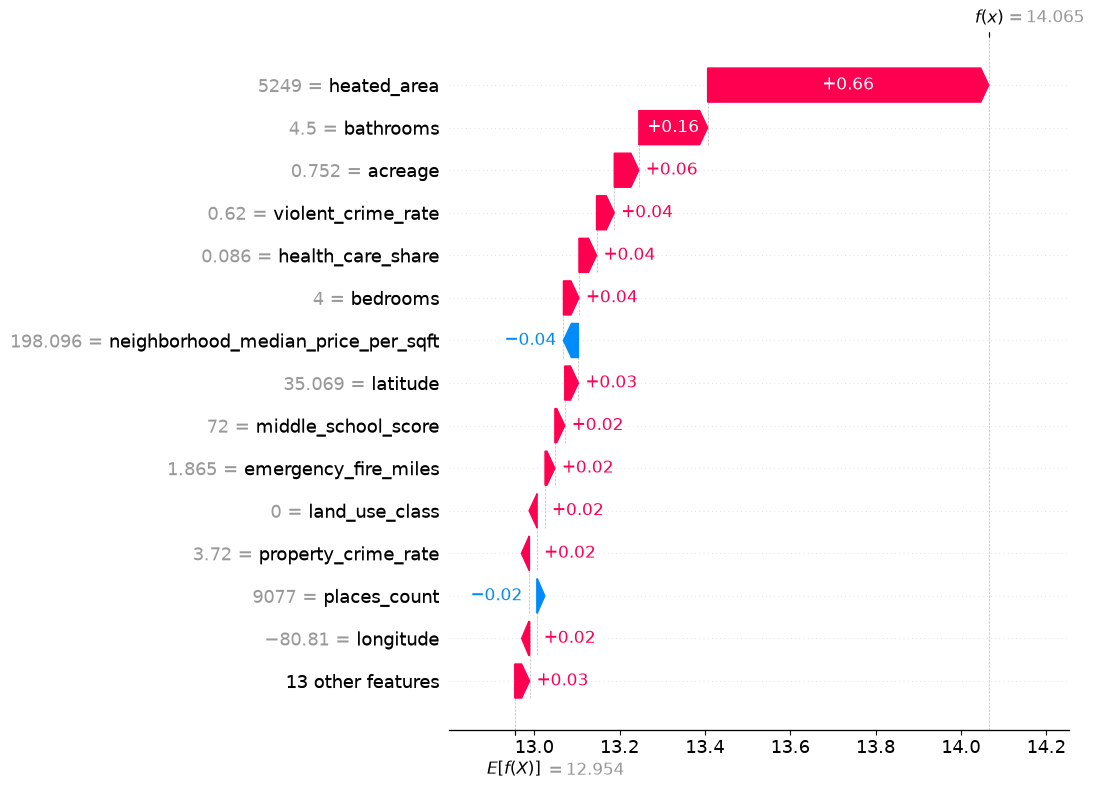

3612 Abbey Hill Ln, Charlotte NC 28210 - in test set; assessed $612,600, stage 3 estimate $612,302


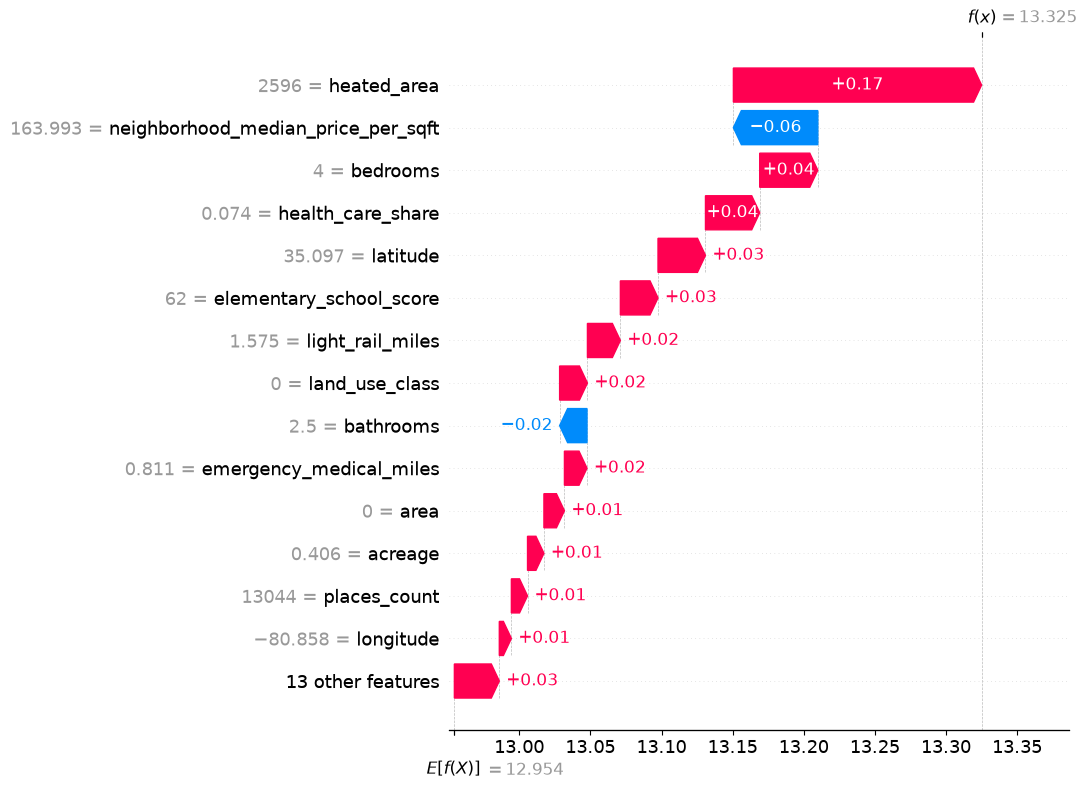

7631 Seton House Ln, Charlotte NC 28277 - in test set; assessed $1,000,000, stage 3 estimate $978,827


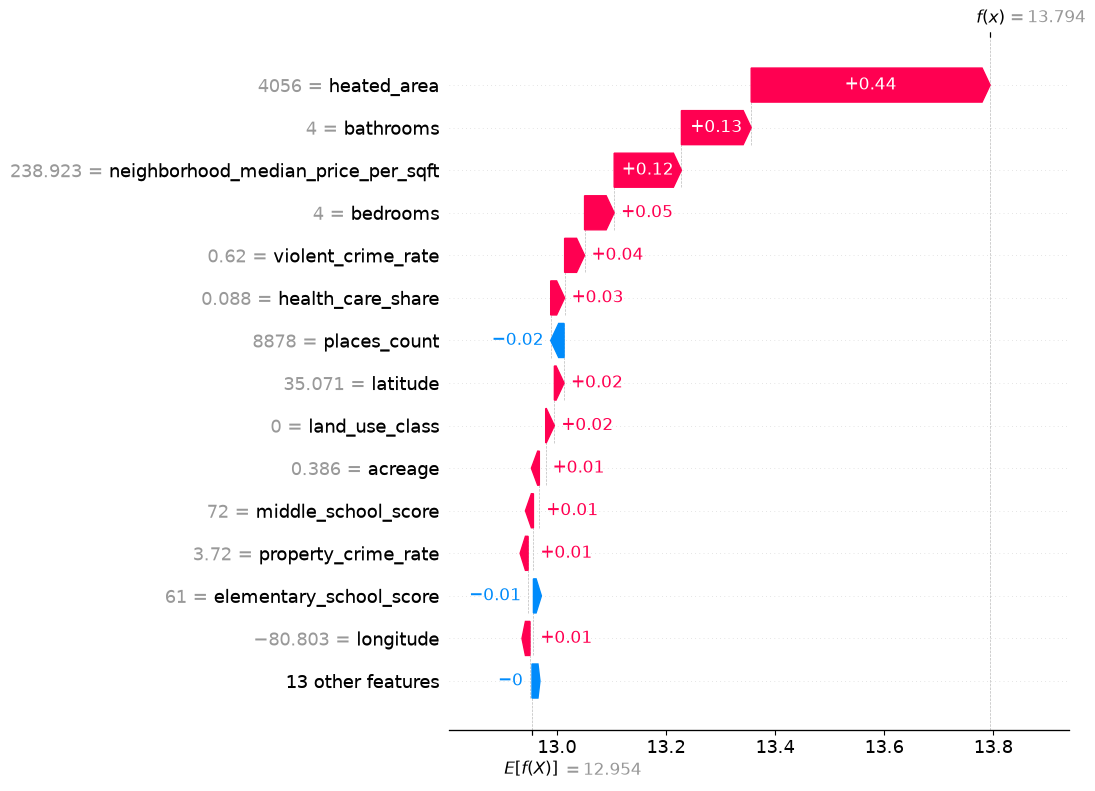

In [13]:
from src.components.search import lookup_property

pre, model, features = models["3. + everything"]
everything = pd.concat([train, test])
for address in cfg["test_addresses"]:
    parcel = lookup_property(address)[0]["parcel_id"]
    house = everything[everything["parcel_id"] == parcel]
    print(address, "- in", "test" if house.index[0] in test.index else "training", "set;",
          f"assessed ${house[TARGET].iloc[0]:,.0f}, stage 3 estimate "
          f"${np.expm1(model.predict(pre.transform(house[features])))[0]:,.0f}")
    shap.plots.waterfall(explain(pre, model, features, house)[0], max_display=15)

## What this shows

**Test error by stage** (gradient boosting with the production settings; the production model is MAE $29,614, 5.10%):

| Stage | MAE | Average error | R squared |
|---|---|---|---|
| 1. House only | $87,566 | 15.19% | 0.764 |
| 1b. House + accessibility | $33,067 | 5.62% | 0.953 |
| 1c. House + flood zone | $87,337 | 15.15% | 0.764 |
| 2. + Neighborhood | $30,682 | 5.25% | 0.957 |
| 3. + Everything else | $29,413 | 5.08% | 0.963 |
| 3b. Everything except neighborhood price | $29,862 | 5.18% | 0.963 |

Differences of about 0.1 points are within noise. Changing only the order of the features moved stages 2 and 3
by 0.02 points, and the drop-column test (`reports/drop_column.csv`) measured a seed noise of 0.05 to 0.07 points.

1. **The house alone explains most of the variation (R squared 0.76) but misses by 15% on average.** Heated area
   is by far the strongest feature (mean |SHAP| 0.288), then bathrooms (0.076). Age and lot size add a little.
2. **Neighborhood is the biggest single improvement**, cutting the error from 15.2% to 5.3%.
   - **Accessibility on its own gets almost as far** (stage 1b): with no location or neighborhood price, it cuts the
     error from 15.2% to 5.6%, about 96% of the gain the neighborhood gives. The accessibility group's mean |SHAP|
     is 0.206 (about 23%). Most of it is `places_count` (0.098) and `health_care_share` (0.089), then the distances
     to medical (0.038) and police (0.037). Without the neighborhood price, these features stand in for location:
     they say how built-up and central a house is.
   - **The flood zone on its own adds almost nothing overall** (stage 1c): 15.19% to 15.15%. Only 0.6% of houses are
     in a floodplain (5 of the 500 explained). For the 388 floodplain houses in the test set, the model raises
     the estimate by about 10% (mean SHAP +0.099). With all location features known (stage 3), the flood zone's
     effect is about 0, so the 10% is probably location and not the flood zone itself.
3. **With everything known, the rest adds a small further gain** (5.25% to 5.08%). In mean |SHAP|: neighborhood
   price 0.117, accessibility 0.057, school 0.056, location (area, coordinates, sales, momentum) 0.029, crime
   0.021, light rail 0.007, flood zone 0.0004.
   - `elementary_school_score` is the 5th most important feature, ahead of lot size. `places_count` is 7th,
     `health_care_share` 10th and `violent_crime_rate` 11th.
   - Directions are as expected: higher school scores and more health care nearby raise the estimate (correlation
     of value and SHAP +0.91 and +0.90), more violent crime lowers it (−0.74).
4. **Without the neighborhood price (stage 3b), its credit moves to accessibility and schools**, and the error
   barely changes (5.08% to 5.18%, about noise). Accessibility doubles (0.057 to 0.115), school rises
   (0.056 to 0.076), location (0.029 to 0.043) and light rail (0.007 to 0.015) rise a little. `places_count`
   becomes the 2nd most important feature and `elementary_school_score` the 3rd. The neighborhood price is a
   summary of what accessibility, schools and location already say.
5. **The test houses** (all held out of training):
   - **4817 Kelly Woods Ln**: estimate $1,283,815 against an assessed $1,191,900 (+7.7%). Its size (5,249 sq ft)
     carries most of it (+0.66), then bathrooms (+0.16). The neighborhood price ($198 per sq ft) adds about
     nothing: many of the neighborhood's sales are from 2016-2019, when prices were much lower.
   - **3612 Abbey Hill Ln**: estimate $612,302 against an assessed $612,600 (−0.0%). Size adds +0.17 and the
     neighborhood price ($164 per sq ft) takes off −0.06. Nearby health care adds +0.04.
   - **7631 Seton House Ln**: estimate $978,827 against an assessed $1,000,000 (−2.1%). Size (4,056 sq ft) adds
     +0.44, bathrooms +0.13 and the neighborhood price ($239 per sq ft) +0.12.

**Limits**
- SHAP shows what the model relies on, not what causes value. Features that move together (neighborhood price,
  accessibility, schools, crime) share credit, so a group's number here is smaller than its effect on its own.
  `reports/drop_column.csv` measures each group's unique value. `notebooks/area_effect.ipynb` measures what the
  whole location is worth for the same house.
- `neighborhood_median_price_per_sqft` is a median over 10 years of sales, so in neighborhoods whose prices rose a
  lot (like Kelly Woods') it understates today's level.
- The beeswarm colors for `area` and `land_use_class` are category codes, not low/high values.
